# Exemplo 2 — três setores geográficos

Reprodução auditada do Exemplo 2 da planilha oficial: 25 contrapartes, alocação exclusiva entre EUA, Japão e Europa, e fatores Gama independentes.

In [1]:
# Carrega a carteira e valida a topologia setorial.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import calculate_loss_distribution_detailed

portfolio = data.create_example_2_3sector_portfolio()
sector_columns = [c for c in portfolio if c.startswith('sector_weight_')]
weights = portfolio[sector_columns].to_numpy()
assert np.allclose(weights.sum(axis=1), 1.0)
assert np.all((weights == 0) | (weights == 1))
display(portfolio.head())

,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_US,sector_weight_Japan,sector_weight_Europe
0,1,358475,H,0.30,0.150,1.0,0.0,0.0
1,2,1089819,H,0.30,0.150,0.0,1.0,0.0
2,3,1799710,F,0.10,0.050,0.0,1.0,0.0
3,4,1933116,G,0.15,0.075,1.0,0.0,0.0
4,5,2317327,G,0.15,0.075,0.0,0.0,1.0


In [2]:
# Calcula cada fator pela recursão A10 e combina as PGFs por convolução FFT.
result = calculate_loss_distribution_detailed(
    portfolio.exposure, portfolio.mean_default_rate, portfolio.std_default_rate,
    np.zeros(len(portfolio)), sector_weights_matrix=weights,
    max_loss_dollars=150_000_000,
)
sector_table = pd.DataFrame([vars(p) for p in result.sector_parameters], index=sector_columns)
display(sector_table)
assert result.tail_mass_upper_bound < 1e-8

,mean_defaults,std_defaults,expected_loss_units,alpha,beta,negative_binomial_p
sector_weight_US,1.261400,0.630700,28.494822,4.0,0.315350,0.239746
sector_weight_Japan,0.822094,0.411047,12.613870,4.0,0.205523,0.170485
sector_weight_Europe,1.050868,0.525434,29.161251,4.0,0.262717,0.208057


In [3]:
# Regressão contra os outputs do XLS.
reference_el, reference_var99 = 14_221_863.0, 49_931_502.0
reported = pd.Series({
    'EL': result.expected_loss,
    'VaR99 discreto': result.quantile(.99),
    'VaR99 interpolado como XLS': result.quantile(.99, interpolate=True),
    'Massa truncada': result.tail_mass_upper_bound,
})
display(reported.to_frame('valor'))
assert abs(result.expected_loss-reference_el) < 1
assert abs(result.quantile(.99, interpolate=True)-reference_var99) < 1

,valor
EL,1.422186e+07
VaR99 discreto,4.999008e+07
VaR99 interpolado como XLS,4.993150e+07
Massa truncada,6.623797e-09


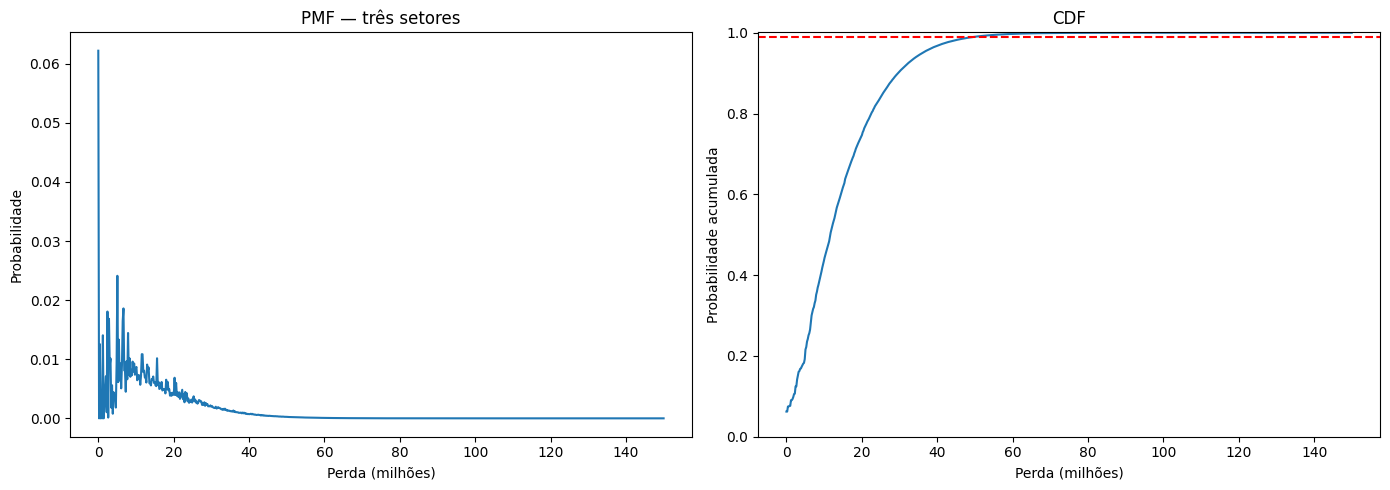

In [4]:
# Distribuição completa sem renormalização da cauda truncada.
losses = np.arange(len(result.pmf))*result.unit_size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses/1e6, result.pmf)
axes[0].set(title='PMF — três setores', xlabel='Perda (milhões)', ylabel='Probabilidade')
axes[1].plot(losses/1e6, result.cdf)
axes[1].axhline(.99, color='red', ls='--')
axes[1].set(title='CDF', xlabel='Perda (milhões)', ylabel='Probabilidade acumulada', ylim=(0, 1.001))
plt.tight_layout(); plt.show()

A diversificação entre fatores independentes reduz a cauda em relação ao caso de um único setor. Isso é uma hipótese estrutural: dependência entre os fatores geográficos exigiria outra especificação, não uma alteração ad hoc da recursão.